In [1]:
from pathlib import Path

from cr_knee_fit.analysis import FitConfig
from cr_knee_fit.fit_data import Data
from cr_knee_fit.model import Model

In [2]:
from cr_knee_fit.inference import GoodnessOfFit


def load_mle_model(outdir: Path | str) -> tuple[FitConfig, Model, GoodnessOfFit]:
    outdir = Path(outdir)
    config_path = outdir / "config-dump.json"
    config = FitConfig.model_validate_json(config_path.read_text())
    m = Model.load(outdir / "mle-prelim.txt", layout_info=config.model)
    assert m is not None, "MLE model not found"
    return (config, m, GoodnessOfFit.load(outdir / "mle-prelim.gof.json"))

In [3]:
import numpy as np
from scipy import stats


def get_significance(twopop_dir: str, verbose: bool = False):
    log = print if verbose else lambda x: None
    *_, two_res = load_mle_model(twopop_dir)
    *_, three_res = load_mle_model(twopop_dir.replace("2pop", "3pop"))

    log(f"2pop: {two_res}, AIC p = {np.exp(0.5 * (three_res.aic - two_res.aic))}")
    log(f"3pop: {three_res}")

    TS = 2 * (three_res.logpost - two_res.logpost)
    ndof = two_res.ndof - three_res.ndof
    log(f"TS = {TS:.4g}, approximately following chi2 with ndof = {ndof}")
    p = 1 - stats.chi2.cdf(TS, ndof)
    log(f"pvalue = {p:.4g}")

    sigma = stats.norm.ppf(1 - p / 2)
    log(f"-> {sigma:.4g} sigma significance")

    return sigma

# Third population significance in the fiducial model

In [4]:
get_significance("../out/3pop_significance/2pop/lhaaso_sibyll/lambda=1.0", verbose=True)

2pop: logpost = -246.441; D / ndof = 514 / 827 = 0.6216; AIC = 554.882, AIC p = 0.030736612801211798
3pop: logpost = -237.959; D / ndof = 497.1 / 822 = 0.6047; AIC = 547.917
TS = 16.96, approximately following chi2 with ndof = 5
pvalue = 0.004567
-> 2.836 sigma significance


np.float64(2.836057456024842)

# Logposterior value of the fixed model vs. $\lambda_\text{syst}$

In [17]:
from cr_knee_fit.fit_data import GenericExperimentData
from cr_knee_fit.inference import set_default_chi2_method, set_default_lognormal_chi2


def compute_gofs_vs_lambda_grid(
    lambda_syst_grid: np.ndarray,
    model_dir: str | Path,
) -> tuple[GoodnessOfFit, list[GoodnessOfFit]]:
    set_default_lognormal_chi2(True)

    config, m, _ = load_mle_model(model_dir)

    set_default_chi2_method("dimidated")
    fit_data = Data.load(config.fit_data_config)
    gof_uncorr = GoodnessOfFit.compute(m, fit_data)

    set_default_chi2_method("correlated")

    gofs: list[GoodnessOfFit] = []
    for lambda_syst in lambda_syst_grid:
        GenericExperimentData.default_systematics_correlation_length = lambda_syst
        # HACK: we load the data anew every time, so inv_err_cov is not cached but rather re-computed every time
        fit_data = Data.load(config.fit_data_config)
        gofs.append(GoodnessOfFit.compute(m, fit_data))

    return gof_uncorr, gofs

In [18]:
def compute_sigma_significance(gof1: GoodnessOfFit, gof2: GoodnessOfFit) -> float:
    TS = 2 * (gof2.logpost - gof1.logpost)
    ndof = gof1.ndof - gof2.ndof
    p = 1 - stats.chi2.cdf(TS, ndof)
    return float(stats.norm.ppf(1 - p / 2))

In [24]:
lambda_syst_grid = np.linspace(0.1, 3, 100)
gof_uncorr_1, gofs1 = compute_gofs_vs_lambda_grid(
    lambda_syst_grid, "../out/3pop_significance/2pop/lhaaso_sibyll/lambda=1.0"
)
gof_uncorr_2, gofs2 = compute_gofs_vs_lambda_grid(
    lambda_syst_grid, "../out/3pop_significance/3pop/lhaaso_sibyll/lambda=1.0"
)

/home/nj-vs-vh/Documents/Science/cr-knee-fit/cr_knee_fit/crams_model.py:543: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.crams.compute(self.propagation, self.injection))


Text(0, 0.5, 'Third population significance / $\\sigma$')

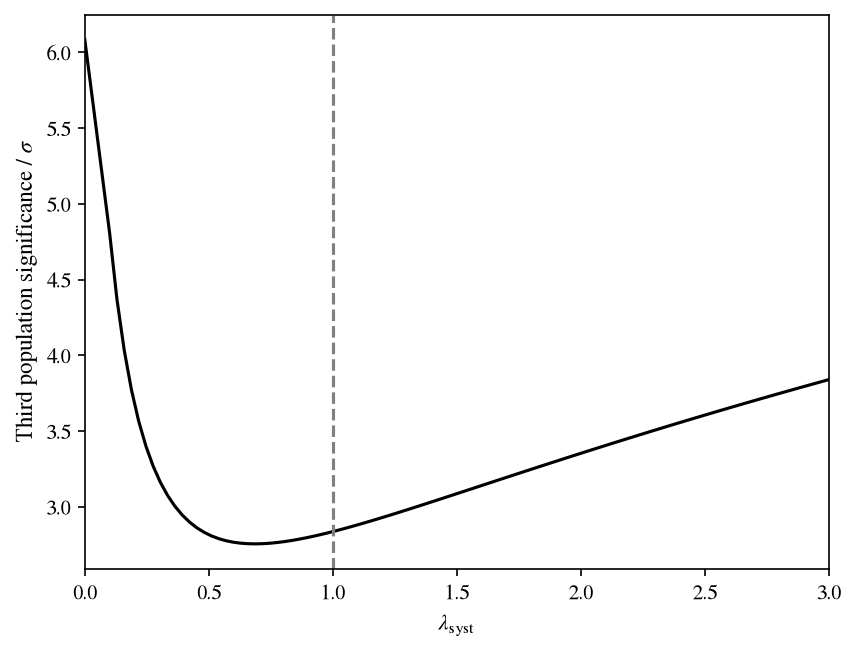

In [26]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

sigma_uncorr = compute_sigma_significance(gof_uncorr_1, gof_uncorr_2)
sigmas = [compute_sigma_significance(gof1, gof2) for gof1, gof2 in zip(gofs1, gofs2)]

ax.plot([0.0, *lambda_syst_grid], [sigma_uncorr, *sigmas], color="k")
ax.axvline(1.0, color="gray", ls="--")
ax.set_xlabel("$\\lambda_\\text{syst}$")
ax.set_xlim(0, lambda_syst_grid[-1])
ax.set_ylabel("Third population significance / $\\sigma$")